# Convolutional Neural Networks in PyTorch

In this lab you will explore how to create a convolutional neural network (CNN) with PyTorch.

The CNN will run slowly unless you have an accelerator (like on newer MacBooks or in Google Colab).  On Colab, make sure to select the GPU runtime in `Runtime > Change runtime type`.

Here I load the Intel Image Classification dataset.  The images have been resized to 32x32.

In [1]:
import os
if not os.path.exists('intel_image_classification.npz'):
  !wget -O intel_image_classification.npz "https://www.dropbox.com/scl/fi/g8piaiw6njhogb7fnu7b3/intel_image_classification.npz?rlkey=8ytc0ucpc7tg2gzs0gxtnzun5&dl=1"  

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
data = np.load('intel_image_classification.npz')
label_names = data['label_names']
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

The dataset has six categories and around 16k images total.

In [4]:
label_names

array(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'],
      dtype='<U9')

In [5]:
X_train.shape, X_train.dtype, X_train.min(), X_train.max()

((13986, 32, 32, 3), dtype('float32'), np.float32(0.0), np.float32(1.0))

In [6]:
y_train.shape, y_train.dtype, y_train.min(), y_train.max()

((13986,), dtype('int64'), np.int64(0), np.int64(5))

In [7]:
len(X_train), len(X_test)

(13986, 2993)

Text(0.5, 1.0, '0')

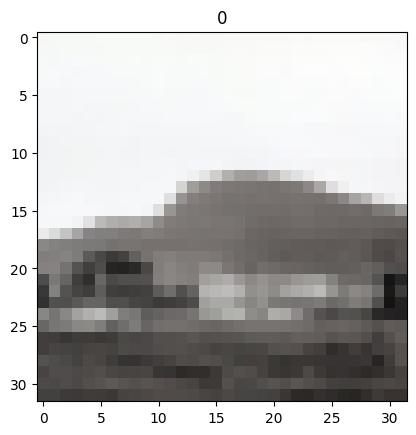

In [8]:
plt.imshow(X_train[0])
plt.title(y_train[0])

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [10]:
X_train_torch = torch.tensor(X_train.transpose((0,3,1,2))) # change dim ordering for PyTorch
y_train_torch = torch.tensor(y_train)
X_test_torch = torch.tensor(X_test.transpose((0,3,1,2))) # change dim ordering for PyTorch
y_test_torch = torch.tensor(y_test)

## Exercises

Create a CNN to classify the images.  Here is a starting point for your architecture, although you are free to put whatever you want into the network:

* Input layer
* 2D convolution, 3x3 kernel, 32 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* 2D convolution, 3x3 kernel, 64 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* 2D convolution, 3x3 kernel, 128 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* Flatten
* Linear layer: 6 outputs

Choose some settings for the optimizer etc. and see what accuracy can you achieve on this dataset.

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
def compute_model_acc(model: torch.nn.Sequential, loader: DataLoader) -> float:
    num_correct = 0
    n = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            z_batch = model(X_batch)
            y_predict = torch.argmax(z_batch, dim=1)
            num_correct += torch.sum(y_predict == y_batch)
            n += len(y_batch)
        
    return num_correct / n

In [17]:
train_ds = TensorDataset(X_train_torch, y_train_torch)
test_ds = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [20]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),

    nn.Linear(128 * 4 * 4, 6)
)

model = model.to(device)

In [21]:
loss_fn = torch.nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 100
for epoch in range(epochs):
    model.train()

    running_correct = 0
    total_samples = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        opt.zero_grad() # zero out the gradients
        z_batch = model(X_batch) # compute z values
        loss = loss_fn(z_batch,y_batch) # compute loss
        loss.backward() # compute gradients
        opt.step() # apply gradients

        # calculate accuracy
        y_predict = torch.argmax(z_batch, dim=1)
        running_correct += (y_predict == y_batch).sum().item()
        total_samples += y_batch.size(0)

    epoch_train_acc = running_correct / total_samples
    print(f'epoch {epoch}: loss is {loss.item():.4f} -- training accuracy is {epoch_train_acc:.4f}, test accuracy is {compute_model_acc(model, test_loader):.4f}')

epoch 0: loss is 0.6811 -- training accuracy is 0.5659, test accuracy is 0.6345
epoch 1: loss is 0.0191 -- training accuracy is 0.6930, test accuracy is 0.7026
epoch 2: loss is 0.1716 -- training accuracy is 0.7356, test accuracy is 0.7203
epoch 3: loss is 0.0580 -- training accuracy is 0.7623, test accuracy is 0.7501
epoch 4: loss is 1.3427 -- training accuracy is 0.7802, test accuracy is 0.7270
epoch 5: loss is 3.4860 -- training accuracy is 0.7972, test accuracy is 0.7668
epoch 6: loss is 0.0218 -- training accuracy is 0.8113, test accuracy is 0.7761
epoch 7: loss is 2.3218 -- training accuracy is 0.8258, test accuracy is 0.7614
epoch 8: loss is 0.0153 -- training accuracy is 0.8307, test accuracy is 0.7771
epoch 9: loss is 1.7160 -- training accuracy is 0.8451, test accuracy is 0.7965
epoch 10: loss is 0.0271 -- training accuracy is 0.8581, test accuracy is 0.7805
epoch 11: loss is 0.5809 -- training accuracy is 0.8723, test accuracy is 0.7718
epoch 12: loss is 0.0569 -- training a

I found that withought regularization, the model was overfitting beyond only ~20 epochs (final train acc was 99.4% and final test acc was 76.4%), so I tried to introduce regularization and switched to the AdamW optimization, which I saw online was found to do better for CNNs than the "regular" Adam. However, trying both AdamW and Adam with varying weight_decay values did not seem to improve the overfitting problem. Other techniques must be considered to try and improve performance. That being said, choosing the model version with the best historical test accuracy would get about 79% training accuracy, which was from an early on epoch (around epoch 15/100).